# PHYS: constrained physical candidate analysis

This notebook is the guided interface for the single-objective physical
tuning workflow. **Lower physical cost is better.** The cost remains the
established equal-weight sum of surface and bottom temperature and
salinity costs.

The workflow deliberately separates:

- **historical evidence**, which retains disallowed and old settings;
- **candidate rules**, edited in `physical_tuning_spec.toml`; and
- **manual run construction**, which happens outside this notebook.

Start in audit mode. Read the short interpretation note after each table
or figure before making a scientific decision. For details and recovery
procedures, see `PHYSICAL_TUNING_GUIDE.md`.

## Version and recovery

The exact pre-redesign notebook is preserved in Git commit `fad2127`
(`snapshot PHYS before constrained tuning redesign`).

Inspect it with:

```bash
git show fad2127:CandidateParameterSetsPhysical.ipynb
```

Recover a separate copy with:

```bash
git show fad2127:CandidateParameterSetsPhysical.ipynb > CandidateParameterSetsPhysical_pre_redesign.ipynb
```

`git restore --source fad2127 -- CandidateParameterSetsPhysical.ipynb`
replaces the active notebook and can discard uncommitted edits. Use that
command only after saving work you want to keep.

## 1. Imports

Stable mechanics live in `physical_candidate_utils.py` so the scientific
decisions remain visible here and in the TOML file.

In [1]:
from pathlib import Path
from importlib import reload
from hashlib import sha256
import json

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display

import physical_candidate_utils as pcu
reload(pcu)

pd.set_option("display.max_columns", 100)

## 2. Control panel — review this cell every time

Safe defaults perform an audit and never request or complete trials.

- `audit`: read, analyze, and write audit tables only.
- `generate_candidates`: create Optuna trial records and candidate tables.
- `register_results`: preview completed mapped runs; actual completion also
  requires `CONFIRM_OPTUNA_COMPLETION = True`.
- `FORCE_REFRESH = True`: ignore the cache and reread every source file.

Candidate-space mode, strategy, allowed values, and approved combinations
belong in `physical_tuning_spec.toml`, not this cell.

In [55]:
# ----- ACTION SAFETY -----
ACTION_MODE = "audit"  # audit | generate_candidates | register_results
CONFIRM_OPTUNA_COMPLETION = False
FORCE_REFRESH = False

# ----- INPUTS (same established locations used by MO-BIO) -----
COST_DIRECTORY = Path("/Users/akbaskind/Desktop/COST_FILES")
OPTIMIZATION_DIRECTORY = Path("/Users/akbaskind/Desktop/Optimization")
FILE_LIST = OPTIMIZATION_DIRECTORY / "FileNames.xlsx"
PARAMETER_LIST = OPTIMIZATION_DIRECTORY / "PhysicalParameterList.csv"

# ----- PROJECT FILES -----
SPEC_FILE = Path("physical_tuning_spec.toml")

# ----- ALL GENERATED OUTPUTS -----
PHYS_OUTPUT_DIRECTORY = Path("/Users/akbaskind/Desktop/Optimization/PHYS")

# ----- QUALITY / DISPLAY -----
COST_THRESHOLD = 200.0
SUSPICIOUS_TINY_ABS = 1e-250
N_EXISTING_RUNS_TO_SHOW = 20
N_NUMERIC_DIFFERENCES_TO_SHOW = 30
SAVE_AUDIT_OUTPUTS = True
SAVE_FIGURES = True

# A new scientific space should normally receive a new study name.
STUDY_NAME = "physical_constrained_v1"
CANDIDATE_BATCH_LABEL = "batch_001"  # increment only for a deliberate new batch
OBJECTIVE_VERSION = "physical_cost_sum_temp_salt_v1"

valid_actions = {"audit", "generate_candidates", "register_results"}
if ACTION_MODE not in valid_actions:
    raise ValueError(f"ACTION_MODE must be one of {sorted(valid_actions)}")

paths = pcu.WorkflowPaths(
    cost_directory=COST_DIRECTORY,
    file_list=FILE_LIST,
    parameter_list=PARAMETER_LIST,
    output_root=PHYS_OUTPUT_DIRECTORY,
)

## 3. Load and validate the scientific specification

The TOML is the authoritative, well-commented place to change scientific
rules. Candidate generation remains blocked until the orientation and
optional-CPP review statuses are explicitly set to `approved`.

Interpretation: blockers below are reminders to make a decision, not
software failures. Do not approve a section until you have reviewed its
archive table later in this notebook.

In [48]:
spec = pcu.load_physical_spec(SPEC_FILE)
spec_fingerprint = pcu.scientific_spec_fingerprint(spec)
blockers = pcu.candidate_generation_blockers(spec)

print(f"Specification: {SPEC_FILE}")
print(f"Scientific fingerprint: {spec_fingerprint[:12]}")
print(f"Candidate mode: {spec['workflow']['candidate_space_mode']}")
print(f"Candidate strategy: {spec['workflow']['candidate_strategy']}")
if blockers:
    print("Candidate generation is BLOCKED pending review:")
    for blocker in blockers:
        print(f"  - {blocker}")
else:
    print("Candidate specification review gates are approved.")

Specification: physical_tuning_spec.toml
Scientific fingerprint: f89fdc8a9685
Candidate mode: component_factorial
Candidate strategy: factorial
Candidate specification review gates are approved.


## 4. Read the archive, cache, and verified corrections

Successful files are not printed one by one. The summary calls attention
only to unreadable files, missing required fields, inconsistent coupled
settings, suspicious tiny nonzero values, or unreasonably high costs.

The corrections CSV changes the analysis copy only; source NetCDF files
are never edited. See the guide before adding a correction.

In [49]:
pcu.ensure_output_layout(paths)
DF_archive_raw, DF_quality_issues, archive_source = pcu.read_archive_with_cache(
    paths,
    spec,
    force_refresh=FORCE_REFRESH,
    cost_threshold=COST_THRESHOLD,
    suspicious_tiny_abs=SUSPICIOUS_TINY_ABS,
)
DF_archive, DF_applied_corrections = pcu.apply_verified_corrections(
    DF_archive_raw, paths.corrections_file
)
DF_archive = pcu.refresh_derived_configuration_fields(DF_archive, spec)

usable_costs = DF_archive["Cost"].notna() & np.isfinite(DF_archive["Cost"])
print(
    f"Archive: {len(DF_archive)} runs; {usable_costs.sum()} usable costs; "
    f"source = {archive_source}."
)
print(
    f"Quality records: {len(DF_quality_issues)}; "
    f"verified corrections applied: {len(DF_applied_corrections)}."
)

if not DF_quality_issues.empty:
    display(
        DF_quality_issues.groupby("category", dropna=False)
        .size().rename("records").reset_index()
    )
if not DF_applied_corrections.empty:
    display(DF_applied_corrections)

Archive: 117 runs; 112 usable costs; source = fresh read.
Quality records: 16; verified corrections applied: 0.


,category,records
0,file read error,10
1,missing parameter,6


**How to interpret the quality summary:** a small number of logged issues
does not invalidate the rest of the archive. Open
`quality_control/physical_data_quality_issues.csv` for the affected runs
and details. Never silently infer a value for an unreadable station file.
Historical values such as `nl_tnu2 = 2` or `4` are not quality errors;
they are merely prohibited for new candidates.

## 5. Cost overview

The total below is exactly the sum of the four retained components. Lower
is better. The component table is a safeguard against choosing a low total
that performs poorly on one important depth or variable.

In [50]:
cost_columns = ["Cost", *pcu.COST_COMPONENT_COLUMNS]
display(
    DF_archive.loc[usable_costs, cost_columns]
    .describe().T[["count", "min", "25%", "50%", "75%", "max"]]
)

DF_best_historical = (
    DF_archive.loc[usable_costs, ["Run Name", pcu.RUN_DATE_COLUMN, *cost_columns]]
    .sort_values(["Cost", pcu.RUN_DATE_COLUMN])
    .head(N_EXISTING_RUNS_TO_SHOW)
)
display(DF_best_historical)

,count,min,25%,50%,75%,max
Cost,112.0,0.167575,0.167575,0.183492,0.662086,1.836462
Surface Temperature Cost,112.0,0.007924,0.011422,0.011474,0.014436,0.020255
Bottom Temperature Cost,112.0,0.009092,0.039187,0.045203,0.054971,0.123678
Surface Salinity Cost,112.0,0.033560,0.033582,0.036592,0.051186,0.510563
Bottom Salinity Cost,112.0,0.080374,0.080374,0.093234,0.469234,1.622454


,Run Name,Run Date,Cost,Surface Temperature Cost,Bottom Temperature Cost,Surface Salinity Cost,Bottom Salinity Cost
79,LHS8_2005,2026-08-12 05:40:05,0.167575,0.011422,0.039187,0.036592,0.080374
76,LHS9_2005,2026-08-12 20:02:54,0.167575,0.011422,0.039187,0.036592,0.080374
88,LHS6_2005,2026-08-13 21:19:24,0.167575,0.011422,0.039187,0.036592,0.080374
85,LHS7_2005,2026-08-13 22:03:11,0.167575,0.011422,0.039187,0.036592,0.080374
92,LHS5_2005,2026-08-16 00:25:23,0.167575,0.011422,0.039187,0.036592,0.080374
80,LHS3_2005,2026-08-18 15:29:29,0.167575,0.011422,0.039187,0.036592,0.080374
91,LHS4_2005,2026-08-19 18:01:39,0.167575,0.011422,0.039187,0.036592,0.080374
78,LHS1_2005,2026-08-20 22:09:28,0.167575,0.011422,0.039187,0.036592,0.080374
83,LHS2_2005,2026-08-21 10:56:57,0.167575,0.011422,0.039187,0.036592,0.080374
94,LHS11_2005,2026-08-24 11:19:12,0.167575,0.011422,0.039187,0.036592,0.080374


**How to interpret these tables:** repeated identical totals are not
independent confirmation if those runs share the same configuration or
output. Use the configuration tables below. A difference in total cost is
scientifically meaningful only after checking which component produced
it and whether the comparison is replicated.

## 6. What configurations actually exist?

These are exact archive observations. They answer what was tested before
any candidate restriction is applied. Run counts matter: a one-run level
is weak evidence even when its cost is excellent.

In [51]:
observed_tables = pcu.observed_configuration_tables(DF_archive, spec)

print("Observed advection bundles")
display(observed_tables["advection"])
print("Observed UV/TS orientation pairs")
display(observed_tables["orientation"])
print("Observed optional CPP combinations")
display(observed_tables["optional_cpp"])

Observed advection bundles


,advection_scheme,temp_horizontal_advection,temp_vertical_advection,salt_horizontal_advection,salt_vertical_advection,Runs,Median_Cost,Best_Cost
3,U3_C4,Upstream3,Centered4,Upstream3,Centered4,45,0.167575,0.167575
1,HSIMT_HSIMT,HSIMT,HSIMT,HSIMT,HSIMT,37,0.183492,0.182920
0,A4_A4,Akima4,Akima4,Akima4,Akima4,28,1.511586,0.870188
4,NaN,NaN,NaN,NaN,NaN,6,0.442374,0.442374
2,MPDATA_MPDATA,MPDATA,MPDATA,MPDATA,MPDATA,1,0.514828,0.514828


Observed UV/TS orientation pairs


,UV orientation,TS orientation,Runs,Median_Cost,Best_Cost
2,MIX_S_UV,MIX_GEO_TS,91,0.183492,0.167575
1,MIX_GEO_UV,MIX_ISO_TS,15,0.176859,0.174475
0,MIX_GEO_UV,MIX_GEO_TS,6,0.173008,0.171075
3,NaN,NaN,5,NaN,NaN


Observed optional CPP combinations


,KANTHA_CLAYSON,CRAIG_BANNER,CANUTO_A,Runs,Median_Cost,Best_Cost
2,True,False,False,58,0.183492,0.182920
0,False,False,False,31,0.167575,0.167575
1,False,False,True,22,0.176859,0.171075
4,NaN,NaN,NaN,5,NaN,NaN
3,True,True,False,1,0.442374,0.442374


**How to interpret these tables:** `Median_Cost` describes typical archive
performance and `Best_Cost` shows the best example, but neither isolates a
causal effect when other settings changed simultaneously. Compare exact
joint rows rather than treating CPP switches as independent when they were
always bundled.

The next cell prints suggested TOML syntax from the archive. It never
rewrites your specification. Copy only combinations you deliberately want
eligible, then change the corresponding review status yourself.

In [52]:
suggestions = pcu.suggested_toml_blocks(observed_tables, spec)
print("Observed orientation pairs (review before copying):\n")
print(suggestions["mixing_orientation"])
print("\nObserved optional CPP states (review before copying):\n")
print(suggestions["optional_cpp_options"])

Observed orientation pairs (review before copying):

[[mixing_orientation.approved_pairs]]
name = "S_UV__GEO_TS"
uv = "MIX_S_UV"
ts = "MIX_GEO_TS"

[[mixing_orientation.approved_pairs]]
name = "GEO_UV__ISO_TS"
uv = "MIX_GEO_UV"
ts = "MIX_ISO_TS"

[[mixing_orientation.approved_pairs]]
name = "GEO_UV__GEO_TS"
uv = "MIX_GEO_UV"
ts = "MIX_GEO_TS"

Observed optional CPP states (review before copying):

[[optional_cpp_options.approved_combinations]]
name = "KANTHA_CLAYSON"
enabled = ["KANTHA_CLAYSON"]

[[optional_cpp_options.approved_combinations]]
name = "none"
enabled = []

[[optional_cpp_options.approved_combinations]]
name = "CANUTO_A"
enabled = ["CANUTO_A"]

[[optional_cpp_options.approved_combinations]]
name = "KANTHA_CLAYSON_and_CRAIG_BANNER"
enabled = ["KANTHA_CLAYSON", "CRAIG_BANNER"]


## 7. Broad evidence versus required-bundle evidence

The all-run view retains information from runs lacking the mass bundle.
The bundle-only view asks a narrower question closer to future candidates.
Large differences between the two views indicate confounding or
interactions and should reduce confidence in a simple “best level” claim.

In [53]:
DF_labeled = pcu.label_historical_factors(DF_archive, spec)
screening_factors = [
    "advection_scheme",
    "nl_tnu2_shared",
    "mixing_orientation_pair",
    "optional_cpp_combination",
]
DF_factor_all = pcu.factor_performance_table(
    DF_labeled, screening_factors, bundle_only=False
)
DF_factor_bundle = pcu.factor_performance_table(
    DF_labeled, screening_factors, bundle_only=True
)

print("All readable runs")
display(DF_factor_all.sort_values(["factor", "median_cost"]))
print("Runs with GLS_MIXING + RI_SPLINES + N2S2_HORAVG")
display(DF_factor_bundle.sort_values(["factor", "median_cost"]))

All readable runs


,factor,level,scope,runs,median_cost,mean_cost,best_cost,worst_cost
3,advection_scheme,U3_C4,all readable runs,45,0.167575,0.179064,0.167575,0.592719
1,advection_scheme,HSIMT_HSIMT,all readable runs,37,0.183492,0.183509,0.182920,0.183692
4,advection_scheme,NaN,all readable runs,1,0.442374,0.442374,0.442374,0.442374
2,advection_scheme,MPDATA_MPDATA,all readable runs,1,0.514828,0.514828,0.514828,0.514828
0,advection_scheme,A4_A4,all readable runs,28,1.511586,1.330406,0.870188,1.836462
9,mixing_orientation_pair,GEO_UV__GEO_TS,all readable runs,6,0.173008,0.666890,0.171075,1.698273
10,mixing_orientation_pair,GEO_UV__ISO_TS,all readable runs,15,0.176859,0.757148,0.174475,1.836462
11,mixing_orientation_pair,S_UV__GEO_TS,all readable runs,91,0.183492,0.414261,0.167575,1.529713
5,nl_tnu2_shared,0.5,all readable runs,61,0.167575,0.543950,0.167575,1.836462
6,nl_tnu2_shared,1.0,all readable runs,41,0.183492,0.282958,0.182920,1.204267


Runs with GLS_MIXING + RI_SPLINES + N2S2_HORAVG


,factor,level,scope,runs,median_cost,mean_cost,best_cost,worst_cost
0,advection_scheme,U3_C4,required bundle only,31,0.167575,0.167575,0.167575,0.167575
1,advection_scheme,NaN,required bundle only,1,0.442374,0.442374,0.442374,0.442374
4,mixing_orientation_pair,S_UV__GEO_TS,required bundle only,32,0.167575,0.176162,0.167575,0.442374
2,nl_tnu2_shared,0.5,required bundle only,31,0.167575,0.167575,0.167575,0.167575
3,nl_tnu2_shared,4.0,required bundle only,1,0.442374,0.442374,0.442374,0.442374
6,optional_cpp_combination,none,required bundle only,31,0.167575,0.167575,0.167575,0.167575
5,optional_cpp_combination,KANTHA_CLAYSON_and_CRAIG_BANNER,required bundle only,1,0.442374,0.442374,0.442374,0.442374


**Decision rule:** a level is not “better” merely because its minimum is
lower. Prefer replicated evidence, inspect medians and ranges, and look for
agreement between broad and bundle-only views. If the bundle-only table
contains only one level, the archive cannot answer that comparison under
the required bundle; the missing cells are exactly what a factorial can
test.

/var/folders/9k/5r38tm8d21g6nm3w9rchrd6m0000gn/T/ipykernel_29122/3262874064.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=levels, showfliers=True)
/var/folders/9k/5r38tm8d21g6nm3w9rchrd6m0000gn/T/ipykernel_29122/3262874064.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=levels, showfliers=True)
/var/folders/9k/5r38tm8d21g6nm3w9rchrd6m0000gn/T/ipykernel_29122/3262874064.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(values, labels=levels, showfliers=True)


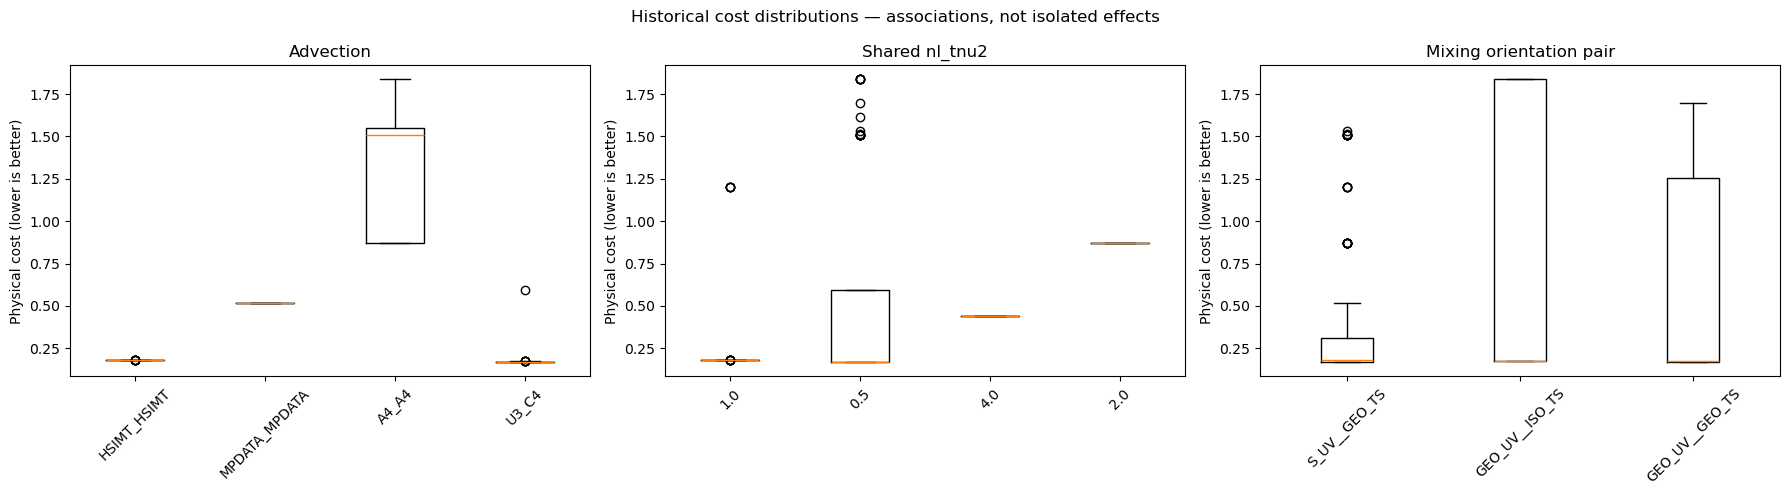

In [61]:
plot_specs = [
    ("advection_scheme", "Advection"),
    ("nl_tnu2_shared", "Shared nl_tnu2"),
    ("mixing_orientation_pair", "Mixing orientation pair"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, (factor, title) in zip(axes, plot_specs):
    data = DF_labeled.dropna(subset=[factor, "Cost"])
    levels = list(dict.fromkeys(data[factor].astype(str)))
    values = [data.loc[data[factor].astype(str).eq(level), "Cost"] for level in levels]
    axis.boxplot(values, labels=levels, showfliers=True)
    axis.set_title(title)
    axis.set_ylabel("Physical cost (lower is better)")
    axis.tick_params(axis="x", rotation=45)
fig.suptitle("Historical cost distributions — associations, not isolated effects")
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(paths.figure_directory / "physical_factor_cost_distributions.png", dpi=200)
plt.show()

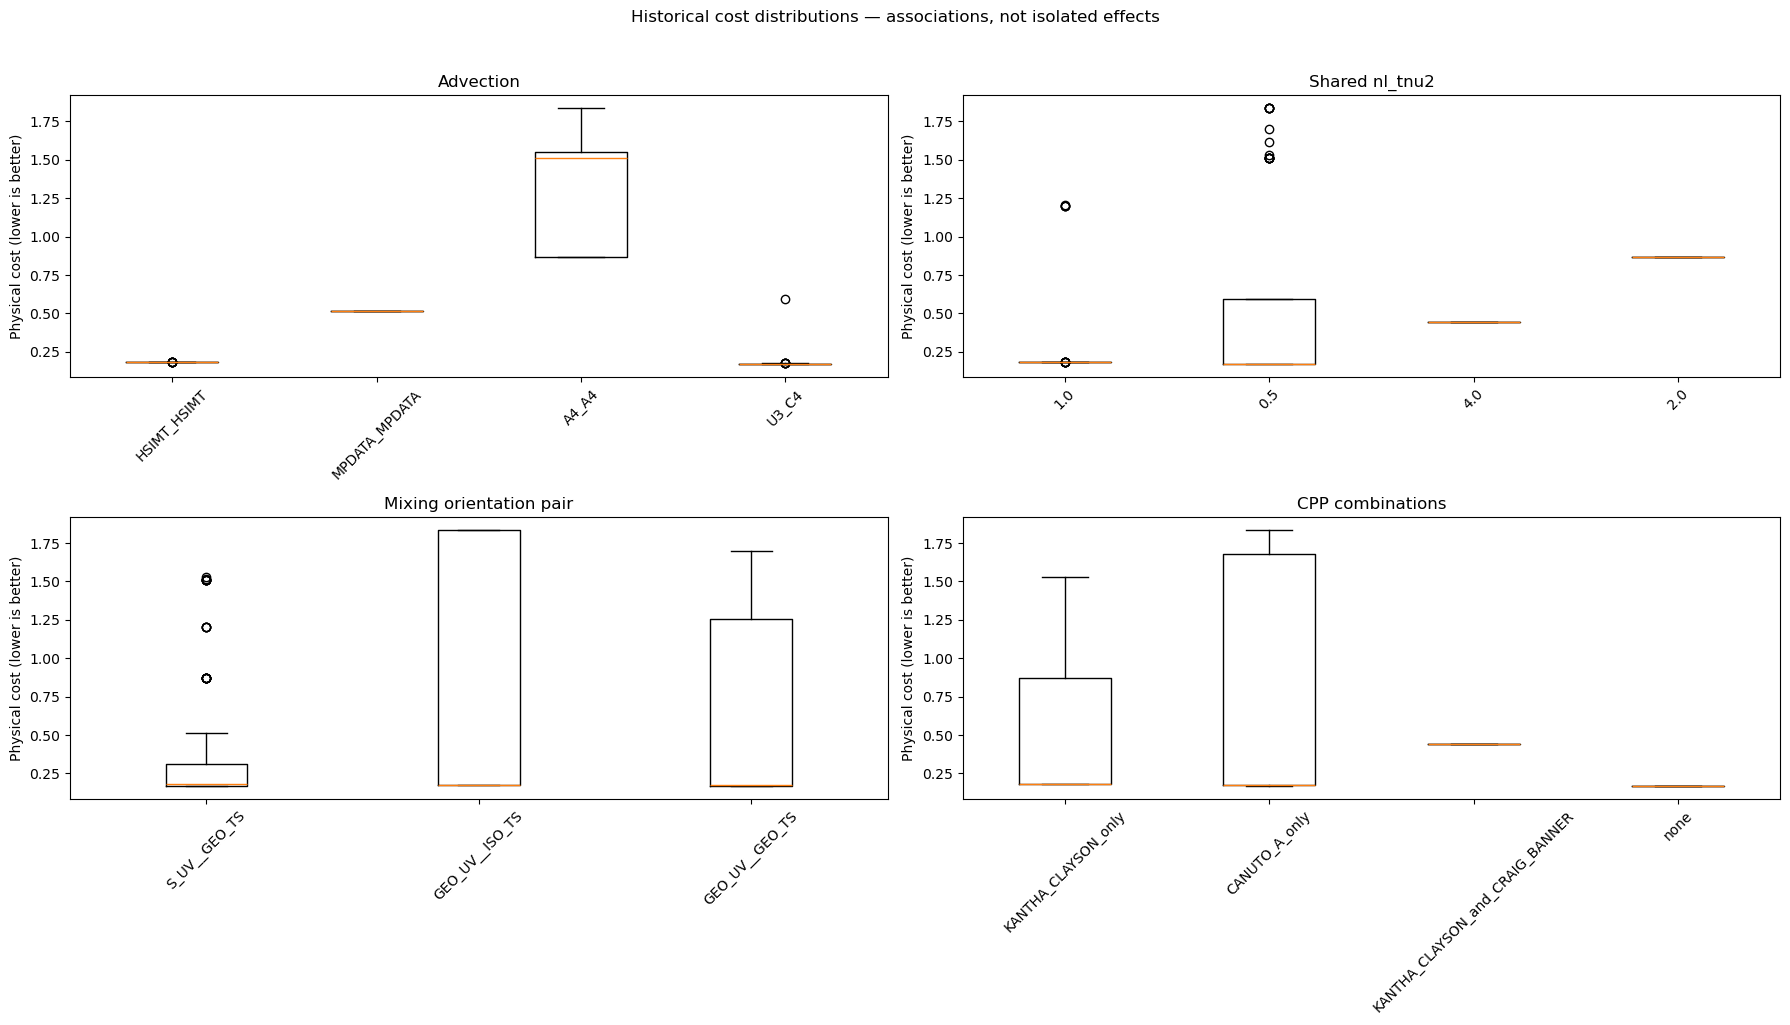

In [62]:
plot_specs = [
  ("advection_scheme", "Advection"),
  ("nl_tnu2_shared", "Shared nl_tnu2"),
  ("mixing_orientation_pair", "Mixing orientation pair"),
  ("optional_cpp_combination", "CPP combinations"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for axis, (factor, title) in zip(axes.flat, plot_specs):
    data = DF_labeled.dropna(subset=[factor, "Cost"]).copy()

    if data.empty:
        axis.text(
          0.5,
          0.5,
          f"No usable data for\n{factor}",
          ha="center",
          va="center",
          transform=axis.transAxes,
        )
        axis.set_title(title)
        axis.set_axis_off()
        continue

    data[factor] = data[factor].astype(str)
    levels = list(dict.fromkeys(data[factor]))
    values = [
      data.loc[data[factor].eq(level), "Cost"]
      for level in levels
    ]

    axis.boxplot(
      values,
      tick_labels=levels,
      showfliers=True,
    )
    axis.set_title(title)
    axis.set_ylabel("Physical cost (lower is better)")
    axis.tick_params(axis="x", rotation=45)

fig.suptitle(
  "Historical cost distributions — associations, not isolated effects",
  y=1.02,
)
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
      paths.figure_directory / "physical_factor_cost_distributions.png",
      dpi=200,
      bbox_inches="tight",
    )

plt.show()

**How to read the figure:** the center line is the median, the box is the
middle half of runs, whiskers show the usual non-outlier range, and points
beyond it are outliers. Narrow boxes can reflect repeated duplicate-like
runs rather than certainty. Overlap means the archive does not cleanly
distinguish levels, especially when factors are confounded.

## 8. Is the best allowed configuration already in the archive?

Candidate-compatible means: allowed advection, shared `nl_tnu2` of 0.5 or
1, complete mass bundle, approved orientation pair, and approved optional
CPP state. Pending TOML lists are used provisionally for this audit, but
no candidate can be generated until their review statuses are approved.

In [57]:
DF_existing_candidates = (
    DF_labeled.loc[DF_labeled["candidate_compatible"]]
    .sort_values(["Cost", pcu.RUN_DATE_COLUMN])
    .copy()
)
existing_columns = [
    "Run Name", pcu.RUN_DATE_COLUMN, "Cost", *pcu.COST_COMPONENT_COLUMNS,
    "advection_scheme", "nl_tnu2_shared", "mixing_orientation_pair",
    "optional_cpp_combination",
]
print(f"Candidate-compatible historical runs: {len(DF_existing_candidates)}")
display(DF_existing_candidates[existing_columns].head(N_EXISTING_RUNS_TO_SHOW))

Candidate-compatible historical runs: 31


,Run Name,Run Date,Cost,Surface Temperature Cost,Bottom Temperature Cost,Surface Salinity Cost,Bottom Salinity Cost,advection_scheme,nl_tnu2_shared,mixing_orientation_pair,optional_cpp_combination
79,LHS8_2005,2026-08-12 05:40:05,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none
76,LHS9_2005,2026-08-12 20:02:54,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none
88,LHS6_2005,2026-08-13 21:19:24,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none
85,LHS7_2005,2026-08-13 22:03:11,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none
92,LHS5_2005,2026-08-16 00:25:23,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none
80,LHS3_2005,2026-08-18 15:29:29,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none
91,LHS4_2005,2026-08-19 18:01:39,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none
78,LHS1_2005,2026-08-20 22:09:28,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none
83,LHS2_2005,2026-08-21 10:56:57,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none
94,LHS11_2005,2026-08-24 11:19:12,0.167575,0.011422,0.039187,0.036592,0.080374,U3_C4,0.5,S_UV__GEO_TS,none


**How to interpret this table:** a good existing run may provide a usable
configuration immediately, but repeated rows with the same settings do
not compare the untested alternatives. If all eligible rows occupy one
exact cell, the archive identifies a strong baseline—not the best level of
every factor.

## 9. Which numeric parameters really varied?

PHYS reads all listed physical numeric fields. Only historically varied
fields appear below. The latest run is selected from the full timestamp in
the station-file `history` attribute, not filename or modification time.
Unspecified varied numeric fields remain fixed to that latest value in new
candidate summaries.

In [40]:
metadata_numeric = {"configuration_index", "optuna_trial_number"}
DF_numeric_inventory = pcu.varied_numeric_inventory(
    DF_archive, metadata_columns=metadata_numeric
)
latest_run = pcu.latest_reference_run(DF_archive)
DF_latest_numeric, DF_numeric_differences = pcu.numeric_differences_from_latest(
    DF_archive, DF_numeric_inventory
)

print(
    f"Latest station-history run: {latest_run['Run Name']} "
    f"({latest_run[pcu.RUN_DATE_COLUMN]})"
)
display(DF_numeric_inventory)
display(DF_latest_numeric)

Latest station-history run: OPTUNA_77 (2026-09-18 20:46:28)


,parameter,historical_unique_count,historical_values,minimum,maximum
0,Akt_bak_tracer10,2,"5e-07, 5e-06",5.000000e-07,0.000005
1,Akt_bak_tracer11,2,"5e-07, 5e-06",5.000000e-07,0.000005
2,Akt_bak_tracer12,2,"5e-07, 5e-06",5.000000e-07,0.000005
3,Akt_bak_tracer13,2,"5e-07, 5e-06",5.000000e-07,0.000005
4,Akt_bak_tracer14,2,"5e-07, 5e-06",5.000000e-07,0.000005
...,...,...,...,...,...
72,nl_tnu2_tracer6,3,"0.5, 1, 4",5.000000e-01,4.000000
73,nl_tnu2_tracer7,3,"0.5, 1, 4",5.000000e-01,4.000000
74,nl_tnu2_tracer8,3,"0.5, 1, 4",5.000000e-01,4.000000
75,nl_tnu2_tracer9,3,"0.5, 1, 4",5.000000e-01,4.000000


,parameter,latest_run,latest_completion,latest_value
0,Akt_bak_tracer10,OPTUNA_77,2026-09-18 20:46:28,0.000005
1,Akt_bak_tracer11,OPTUNA_77,2026-09-18 20:46:28,0.000005
2,Akt_bak_tracer12,OPTUNA_77,2026-09-18 20:46:28,0.000005
3,Akt_bak_tracer13,OPTUNA_77,2026-09-18 20:46:28,0.000005
4,Akt_bak_tracer14,OPTUNA_77,2026-09-18 20:46:28,0.000005
...,...,...,...,...
72,nl_tnu2_tracer6,OPTUNA_77,2026-09-18 20:46:28,0.500000
73,nl_tnu2_tracer7,OPTUNA_77,2026-09-18 20:46:28,0.500000
74,nl_tnu2_tracer8,OPTUNA_77,2026-09-18 20:46:28,0.500000
75,nl_tnu2_tracer9,OPTUNA_77,2026-09-18 20:46:28,0.500000


**How to interpret these tables:** `historical_values` is an inventory,
not an invitation to test every value. The current policy activates only
the coupled physical `nl_tnu2`; every other varied numeric field is shown
for provenance and fixed to the latest run unless the TOML is deliberately
extended in a future revision.

In [41]:
if DF_numeric_differences.empty:
    print("No historical numeric differences from the latest run were found.")
else:
    display(
        DF_numeric_differences.sort_values(
            [pcu.RUN_DATE_COLUMN, "Run Name", "parameter"],
            ascending=[False, True, True],
        ).head(N_NUMERIC_DIFFERENCES_TO_SHOW)
    )

,Run Name,Run Date,Cost,parameter,run_value,latest_value,latest_run
2162,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer10,5.000000e-07,0.000005,OPTUNA_77
2163,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer11,5.000000e-07,0.000005,OPTUNA_77
2164,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer12,5.000000e-07,0.000005,OPTUNA_77
2165,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer13,5.000000e-07,0.000005,OPTUNA_77
2166,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer14,5.000000e-07,0.000005,OPTUNA_77
2167,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer15,5.000000e-07,0.000005,OPTUNA_77
2168,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer16,5.000000e-07,0.000005,OPTUNA_77
2169,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer2,5.000000e-07,0.000005,OPTUNA_77
2170,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer3,5.000000e-07,0.000005,OPTUNA_77
2171,C12,2026-04-24 23:26:05,0.176859,Akt_bak_tracer4,5.000000e-07,0.000005,OPTUNA_77


## 10. Provisional constrained factorial audit

This table is built even while review statuses are pending so you can see
the consequences of the current TOML lists. `observed_exactly_in_archive`
means the full four-factor tuple existed—not merely that each component
appeared somewhere.

In [58]:
DF_candidate_space = pcu.build_candidate_space(DF_archive, spec)
DF_candidate_space_summary = pcu.candidate_space_summary(DF_candidate_space)
display(DF_candidate_space_summary)
display(DF_candidate_space)

,candidate_cells,observed_cells,new_cells
0,48,1,47


,advection_scheme,nl_tnu2_shared,mixing_orientation_pair,optional_cpp_combination,observed_exactly_in_archive,configuration_index,temp_horizontal_advection,temp_vertical_advection,salt_horizontal_advection,salt_vertical_advection,UV orientation,TS orientation,nl_tnu2_tracer0,nl_tnu2_tracer1,GLS_MIXING,RI_SPLINES,N2S2_HORAVG,KANTHA_CLAYSON,CRAIG_BANNER,CANUTO_A
0,U3_C4,0.5,S_UV__GEO_TS,none,True,1,Upstream3,Centered4,Upstream3,Centered4,MIX_S_UV,MIX_GEO_TS,0.5,0.5,True,True,True,False,False,False
1,U3_C4,0.5,S_UV__GEO_TS,KANTHA_CLAYSON_only,False,2,Upstream3,Centered4,Upstream3,Centered4,MIX_S_UV,MIX_GEO_TS,0.5,0.5,True,True,True,True,False,False
2,U3_C4,0.5,S_UV__GEO_TS,CANUTO_A_only,False,3,Upstream3,Centered4,Upstream3,Centered4,MIX_S_UV,MIX_GEO_TS,0.5,0.5,True,True,True,False,False,True
3,U3_C4,0.5,S_UV__GEO_TS,KANTHA_CLAYSON_and_CRAIG_BANNER,False,4,Upstream3,Centered4,Upstream3,Centered4,MIX_S_UV,MIX_GEO_TS,0.5,0.5,True,True,True,True,True,False
4,U3_C4,0.5,GEO_UV__ISO_TS,none,False,5,Upstream3,Centered4,Upstream3,Centered4,MIX_GEO_UV,MIX_ISO_TS,0.5,0.5,True,True,True,False,False,False
5,U3_C4,0.5,GEO_UV__ISO_TS,KANTHA_CLAYSON_only,False,6,Upstream3,Centered4,Upstream3,Centered4,MIX_GEO_UV,MIX_ISO_TS,0.5,0.5,True,True,True,True,False,False
6,U3_C4,0.5,GEO_UV__ISO_TS,CANUTO_A_only,False,7,Upstream3,Centered4,Upstream3,Centered4,MIX_GEO_UV,MIX_ISO_TS,0.5,0.5,True,True,True,False,False,True
7,U3_C4,0.5,GEO_UV__ISO_TS,KANTHA_CLAYSON_and_CRAIG_BANNER,False,8,Upstream3,Centered4,Upstream3,Centered4,MIX_GEO_UV,MIX_ISO_TS,0.5,0.5,True,True,True,True,True,False
8,U3_C4,0.5,GEO_UV__GEO_TS,none,False,9,Upstream3,Centered4,Upstream3,Centered4,MIX_GEO_UV,MIX_GEO_TS,0.5,0.5,True,True,True,False,False,False
9,U3_C4,0.5,GEO_UV__GEO_TS,KANTHA_CLAYSON_only,False,10,Upstream3,Centered4,Upstream3,Centered4,MIX_GEO_UV,MIX_GEO_TS,0.5,0.5,True,True,True,True,False,False


**How to interpret the factorial audit:** `new_cells` are proposed
experiments, not predictions. In component-factorial mode, every internal
pair/bundle is approved but the complete cross-factor configuration may be
new. If the total is affordable, a factorial gives direct coverage. If it
is too large, reduce scientifically unnecessary levels or use categorical
TPE with a clearly stated trial budget. Do not reduce the table merely to
make the code finish faster.

## 11. Save audit products

These CSVs are the durable evidence behind the notebook displays. Files
are written under the configured PHYS output directory, never beside the
notebook.

In [43]:
if SAVE_AUDIT_OUTPUTS:
    pcu.save_audit_outputs(
        paths,
        DF_archive,
        DF_quality_issues,
        observed_tables,
        DF_numeric_inventory,
        DF_numeric_differences,
        DF_candidate_space,
    )
    DF_existing_candidates.to_csv(
        paths.audit_directory / "physical_existing_candidate_runs.csv",
        index=False,
    )
    pd.concat([DF_factor_all, DF_factor_bundle], ignore_index=True).to_csv(
        paths.audit_directory / "physical_historical_performance.csv",
        index=False,
    )
    print(f"Audit outputs saved under: {paths.output_root}")
else:
    print("Audit output writing is disabled.")

Audit outputs saved under: /Users/akbaskind/Desktop/Optimization/PHYS


## 12. Optuna study and action gate

Historical runs remain in the archive evidence tables; they are not
forced into an incompatible Optuna distribution. The fresh Optuna study
tracks only candidate configurations created under one scientific
fingerprint.

This section does nothing in `audit` mode. It refuses generation when a
TOML review is pending or when the stored study fingerprint is different.

In [44]:
study = None
storage = f"sqlite:///{paths.study_database}"

if ACTION_MODE != "audit":
    sampler = optuna.samplers.TPESampler(
        n_startup_trials=8,
        multivariate=True,
        seed=int(spec["workflow"]["random_seed"]),
    )
    study = optuna.create_study(
        study_name=STUDY_NAME,
        storage=storage,
        direction="minimize",
        sampler=sampler,
        load_if_exists=True,
    )
    expected_attrs = {
        "Objective Version": OBJECTIVE_VERSION,
        "Scientific Spec Fingerprint": spec_fingerprint,
    }
    for key, expected in expected_attrs.items():
        stored = study.user_attrs.get(key)
        if stored is None:
            study.set_user_attr(key, expected)
        elif stored != expected:
            raise ValueError(
                f"Study {key} mismatch: stored={stored!r}, current={expected!r}. "
                "Use a fresh study name/database for a changed scientific space."
            )
    print(f"Study: {study.study_name}; stored trials: {len(study.trials)}")
else:
    print("Audit mode: Optuna storage was not opened or modified.")

/var/folders/9k/5r38tm8d21g6nm3w9rchrd6m0000gn/T/ipykernel_29122/2149245645.py:5: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
[I 2026-09-20 14:15:29,126] A new study created in RDB with name: physical_constrained_v1


Study: physical_constrained_v1; stored trials: 0


## 13. Generate candidate records (no ROMS files)

This section creates only Optuna trial records and two CSV descriptions:
a complete candidate summary and a manual change manifest. It also adds
blank mapping rows without overwriting your run names or notes.

`PHYS_XXX` is permanently derived from the Optuna trial number. The run
map records which actual model run that identifier eventually becomes.

In [45]:
DF_candidates = pd.DataFrame()
DF_change_manifest = pd.DataFrame()

if ACTION_MODE == "generate_candidates":
    if blockers:
        raise RuntimeError(
            "Candidate generation is blocked. Resolve TOML review gates first:\n- "
            + "\n- ".join(blockers)
        )
    if DF_candidate_space.empty:
        raise RuntimeError("The approved candidate space is empty.")

    factor_columns = [
        "advection_scheme",
        "nl_tnu2_shared",
        "mixing_orientation_pair",
        "optional_cpp_combination",
    ]
    choices = {
        column: DF_candidate_space[column].drop_duplicates().tolist()
        for column in factor_columns
    }
    batch_fingerprint = sha256(
        (spec_fingerprint + "|" + STUDY_NAME + "|" + CANDIDATE_BATCH_LABEL).encode()
    ).hexdigest()
    waiting_batch = [
        trial for trial in study.trials
        if trial.user_attrs.get("Candidate Batch Fingerprint") == batch_fingerprint
        and trial.state == optuna.trial.TrialState.WAITING
    ]
    if waiting_batch:
        raise RuntimeError(
            "This candidate batch contains partially queued WAITING trials. "
            "Inspect the study before retrying generation."
        )
    existing_batch = [
        trial for trial in study.trials
        if trial.user_attrs.get("Candidate Batch Fingerprint") == batch_fingerprint
        and trial.state in {
            optuna.trial.TrialState.RUNNING,
            optuna.trial.TrialState.COMPLETE,
            optuna.trial.TrialState.FAIL,
        }
    ]

    selected = []
    trial_numbers = []
    if existing_batch:
        for frozen in existing_batch:
            mask = pd.Series(True, index=DF_candidate_space.index)
            for column in factor_columns:
                mask &= DF_candidate_space[column].eq(frozen.params[column])
            if mask.sum() != 1:
                raise RuntimeError(
                    f"Stored trial {frozen.number} does not resolve to one candidate cell."
                )
            selected.append(DF_candidate_space.loc[mask].iloc[0].to_dict())
            trial_numbers.append(frozen.number)
        print(f"Recovered {len(existing_batch)} existing candidate records.")
    else:
        unresolved = [
            trial for trial in study.trials
            if trial.state in {
                optuna.trial.TrialState.RUNNING,
                optuna.trial.TrialState.WAITING,
            }
        ]
        if unresolved:
            raise RuntimeError(
                "The study contains RUNNING/WAITING trials from another batch. "
                "Resolve them before requesting a new batch."
            )

        strategy = spec["workflow"]["candidate_strategy"]
        if strategy == "factorial":
            requested_rows = [row for _, row in DF_candidate_space.iterrows()]
            for expected in requested_rows:
                fixed = {column: expected[column] for column in factor_columns}
                study.enqueue_trial(
                    fixed,
                    user_attrs={
                        "Candidate Batch Fingerprint": batch_fingerprint,
                        "Candidate Batch Label": CANDIDATE_BATCH_LABEL,
                    },
                )
                trial = study.ask()
                params = {
                    column: trial.suggest_categorical(column, choices[column])
                    for column in factor_columns
                }
                if params != fixed:
                    raise RuntimeError(
                        f"Queued factorial cell changed: expected {fixed}, got {params}."
                    )
                trial.set_user_attr("Candidate Batch Fingerprint", batch_fingerprint)
                trial.set_user_attr("Candidate Batch Label", CANDIDATE_BATCH_LABEL)
                trial.set_user_attr("Candidate ID", f"PHYS_{trial.number:03d}")
                trial.set_user_attr("Source", "constrained factorial")
                selected.append(expected.to_dict())
                trial_numbers.append(trial.number)
        else:
            budget = min(
                int(spec["workflow"]["trial_budget"]), len(DF_candidate_space)
            )
            selected_keys = set()
            attempts = 0
            while len(selected) < budget and attempts < max(100, budget * 20):
                attempts += 1
                trial = study.ask()
                params = {
                    column: trial.suggest_categorical(column, choices[column])
                    for column in factor_columns
                }
                mask = pd.Series(True, index=DF_candidate_space.index)
                for column in factor_columns:
                    mask &= DF_candidate_space[column].eq(params[column])
                if mask.sum() != 1:
                    study.tell(trial, state=optuna.trial.TrialState.PRUNED)
                    continue
                key = tuple(params[column] for column in factor_columns)
                if key in selected_keys:
                    study.tell(trial, state=optuna.trial.TrialState.PRUNED)
                    continue
                selected_keys.add(key)
                trial.set_user_attr("Candidate Batch Fingerprint", batch_fingerprint)
                trial.set_user_attr("Candidate Batch Label", CANDIDATE_BATCH_LABEL)
                trial.set_user_attr("Candidate ID", f"PHYS_{trial.number:03d}")
                trial.set_user_attr("Source", "categorical TPE")
                selected.append(DF_candidate_space.loc[mask].iloc[0].to_dict())
                trial_numbers.append(trial.number)
            if len(selected) < budget:
                raise RuntimeError(
                    f"TPE produced only {len(selected)} unique valid cells of {budget}."
                )

    DF_candidates = pcu.attach_candidate_identity(
        pd.DataFrame(selected),
        trial_numbers,
        STUDY_NAME,
        spec["workflow"]["candidate_strategy"],
        spec_fingerprint,
        str(latest_run["Run Name"]),
    )
    DF_candidates.insert(4, "candidate_batch", CANDIDATE_BATCH_LABEL)

    # Include every other historically varied numeric setting explicitly,
    # fixed to the latest station-history run.
    for parameter in DF_numeric_inventory["parameter"]:
        if parameter not in DF_candidates.columns:
            DF_candidates[parameter] = latest_run.get(parameter, np.nan)

    DF_change_manifest = pcu.build_change_manifest(
        DF_candidates, latest_run, spec
    )
    candidate_file = paths.candidate_directory / "physical_candidate_summary.csv"
    manifest_file = paths.candidate_directory / "physical_candidate_change_manifest.csv"
    DF_candidates.to_csv(candidate_file, index=False)
    DF_change_manifest.to_csv(manifest_file, index=False)
    DF_run_map = pcu.update_run_map(paths.run_map_file, DF_candidates)

    print(f"Candidate records: {len(DF_candidates)}")
    print(f"Summary: {candidate_file}")
    print(f"Manual change manifest: {manifest_file}")
    print(f"Run map: {paths.run_map_file}")
    display(DF_candidates)
    display(DF_change_manifest)
else:
    print("Candidate generation is off.")

Candidate records: 4
Summary: /Users/akbaskind/Desktop/Optimization/PHYS/candidates/physical_candidate_summary.csv
Manual change manifest: /Users/akbaskind/Desktop/Optimization/PHYS/candidates/physical_candidate_change_manifest.csv
Run map: /Users/akbaskind/Desktop/Optimization/PHYS/provenance/physical_candidate_run_map.csv


,candidate_id,optuna_trial_number,study_name,strategy,candidate_batch,advection_scheme,nl_tnu2_shared,mixing_orientation_pair,optional_cpp_combination,observed_exactly_in_archive,configuration_index,temp_horizontal_advection,temp_vertical_advection,salt_horizontal_advection,salt_vertical_advection,UV orientation,TS orientation,nl_tnu2_tracer0,nl_tnu2_tracer1,GLS_MIXING,RI_SPLINES,N2S2_HORAVG,KANTHA_CLAYSON,CRAIG_BANNER,CANUTO_A,latest_reference_run,spec_sha256,generated_at,Akt_bak_tracer10,Akt_bak_tracer11,Akt_bak_tracer12,Akt_bak_tracer13,Akt_bak_tracer14,Akt_bak_tracer15,Akt_bak_tracer16,Akt_bak_tracer2,Akt_bak_tracer3,Akt_bak_tracer4,Akt_bak_tracer5,Akt_bak_tracer6,Akt_bak_tracer7,Akt_bak_tracer8,Akt_bak_tracer9,Tobc_in_14,Tobc_in_17,Tobc_in_18,Tobc_in_22,Tobc_in_23,Tobc_in_28,Tobc_in_30,...,Tobc_in_36,Tobc_in_37,Tobc_in_39,Tobc_in_40,Tobc_in_41,Tobc_in_42,Tobc_in_45,Tobc_in_48,Tobc_in_50,Tobc_in_52,Tobc_in_53,Tobc_in_54,Tobc_out_14,Tobc_out_17,Tobc_out_18,Tobc_out_22,Tobc_out_23,Tobc_out_28,Tobc_out_30,Tobc_out_31,Tobc_out_32,Tobc_out_36,Tobc_out_37,Tobc_out_39,Tobc_out_40,Tobc_out_41,Tobc_out_42,Tobc_out_45,Tobc_out_48,Tobc_out_50,Tobc_out_52,Tobc_out_53,Tobc_out_54,gls_Kmin,nl_tnu2_tracer10,nl_tnu2_tracer11,nl_tnu2_tracer12,nl_tnu2_tracer13,nl_tnu2_tracer14,nl_tnu2_tracer15,nl_tnu2_tracer16,nl_tnu2_tracer2,nl_tnu2_tracer3,nl_tnu2_tracer4,nl_tnu2_tracer5,nl_tnu2_tracer6,nl_tnu2_tracer7,nl_tnu2_tracer8,nl_tnu2_tracer9,nl_visc2
0,PHYS_000,0,physical_constrained_v1,factorial,batch_001,U3_C4,0.5,S_UV__GEO_TS,none,True,1,Upstream3,Centered4,Upstream3,Centered4,MIX_S_UV,MIX_GEO_TS,0.5,0.5,True,True,True,False,False,False,OPTUNA_77,038260a630d22bf0aab8ef4f3385ff6273cac989f9dc8b...,2026-09-20T14:16:05,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000087,0.000087,0.000087,0.0,0.0,0.000087,0.0,...,0.000087,0.000087,0.0,0.0,0.0,0.0,0.000087,0.000087,0.000087,0.0,0.0,0.0,0.000006,0.000006,0.000006,0.0,0.0,0.000006,0.0,0.000006,0.000006,0.000006,0.000006,0.0,0.0,0.0,0.0,0.000006,0.000006,0.000006,0.0,0.0,0.0,1.000000e-10,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,2.0
1,PHYS_001,1,physical_constrained_v1,factorial,batch_001,U3_C4,1.0,S_UV__GEO_TS,none,False,2,Upstream3,Centered4,Upstream3,Centered4,MIX_S_UV,MIX_GEO_TS,1.0,1.0,True,True,True,False,False,False,OPTUNA_77,038260a630d22bf0aab8ef4f3385ff6273cac989f9dc8b...,2026-09-20T14:16:05,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000087,0.000087,0.000087,0.0,0.0,0.000087,0.0,...,0.000087,0.000087,0.0,0.0,0.0,0.0,0.000087,0.000087,0.000087,0.0,0.0,0.0,0.000006,0.000006,0.000006,0.0,0.0,0.000006,0.0,0.000006,0.000006,0.000006,0.000006,0.0,0.0,0.0,0.0,0.000006,0.000006,0.000006,0.0,0.0,0.0,1.000000e-10,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,2.0
2,PHYS_002,2,physical_constrained_v1,factorial,batch_001,A4_A4,0.5,S_UV__GEO_TS,none,False,3,Akima4,Akima4,Akima4,Akima4,MIX_S_UV,MIX_GEO_TS,0.5,0.5,True,True,True,False,False,False,OPTUNA_77,038260a630d22bf0aab8ef4f3385ff6273cac989f9dc8b...,2026-09-20T14:16:05,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000087,0.000087,0.000087,0.0,0.0,0.000087,0.0,...,0.000087,0.000087,0.0,0.0,0.0,0.0,0.000087,0.000087,0.000087,0.0,0.0,0.0,0.000006,0.000006,0.000006,0.0,0.0,0.000006,0.0,0.000006,0.000006,0.000006,0.000006,0.0,0.0,0.0,0.0,0.000006,0.000006,0.000006,0.0,0.0,0.0,1.000000e-10,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,2.0
3,PHYS_003,3,physical_constrained_v1,factorial,batch_001,A4_A4,1.0,S_UV__GEO_TS,none,False,4,Akima4,Akima4,Akima4,Akima4,MIX_S_UV,MIX_GEO_TS,1.0,1.0,True,True,True,False,False,False,OPTUNA_77,038260a630d22bf0aab8ef4f3385ff6273cac989f9dc8b...,2026-09-20T14:16:05,0.000005,0.000005,0.000005,0.000005,0.000005,0

,candidate_id,optuna_trial_number,setting_group,target_fields,reference_value,candidate_value,action
0,PHYS_000,0,coupled numeric,nl_tnu2_tracer0 + nl_tnu2_tracer1,0.5 + 0.5,0.5,Set both identically
1,PHYS_000,0,coupled advection,temp_horizontal_advection + temp_vertical_adve...,U3_C4,Upstream3 / Centered4,Set both tracers identically
2,PHYS_000,0,CPP option,MIX_S_UV,True,False,Disable
3,PHYS_000,0,CPP option,MIX_ISO_UV,False,False,Disable
4,PHYS_000,0,CPP option,MIX_GEO_UV,False,False,Disable
5,PHYS_000,0,CPP option,MIX_S_TS,False,False,Disable
6,PHYS_000,0,CPP option,MIX_ISO_TS,False,False,Disable
7,PHYS_000,0,CPP option,MIX_GEO_TS,True,False,Disable
8,PHYS_000,0,CPP option,GLS_MIXING,True,True,Enable
9,PHYS_000,0,CPP option,RI_SPLINES,True,True,Enable


**How to use these outputs:** the summary is the complete intended
configuration; the change manifest is a manual editing checklist. PHYS
does not generate, modify, or verify ROMS input files. After assigning a
real run name, fill `actual_run_name` in the run map while preserving the
candidate ID and trial number.

## 14. Preview or register completed mapped runs

A result is matched only through the run map. `register_results` first
displays eligible rows. Optuna changes occur only when
`CONFIRM_OPTUNA_COMPLETION = True` as well.

In [46]:
DF_completion_preview = pd.DataFrame()

if ACTION_MODE == "register_results":
    run_map = pcu.update_run_map(paths.run_map_file, pd.DataFrame(
        columns=["candidate_id", "optuna_trial_number"]
    ))
    archive_by_name = DF_archive.drop_duplicates("Run Name").set_index("Run Name")
    preview = []
    for frozen in study.trials:
        if frozen.state != optuna.trial.TrialState.RUNNING:
            continue
        candidate_id = frozen.user_attrs.get(
            "Candidate ID", f"PHYS_{frozen.number:03d}"
        )
        mapping = run_map.loc[run_map["candidate_id"].eq(candidate_id)]
        if mapping.empty:
            continue
        actual_name = mapping.iloc[0]["actual_run_name"]
        if pd.isna(actual_name) or not str(actual_name).strip():
            continue
        actual_name = str(actual_name).strip()
        if actual_name not in archive_by_name.index:
            continue
        result = archive_by_name.loc[actual_name]
        if pd.isna(result["Cost"]) or not np.isfinite(result["Cost"]):
            continue
        preview.append(
            {
                "candidate_id": candidate_id,
                "optuna_trial_number": frozen.number,
                "actual_run_name": actual_name,
                "Cost": float(result["Cost"]),
                pcu.RUN_DATE_COLUMN: result[pcu.RUN_DATE_COLUMN],
                "action": (
                    "complete in Optuna"
                    if CONFIRM_OPTUNA_COMPLETION else "preview only"
                ),
            }
        )
        if CONFIRM_OPTUNA_COMPLETION:
            live = optuna.trial.Trial(study, frozen._trial_id)
            live.set_user_attr("Actual Run Name", actual_name)
            live.set_user_attr(
                pcu.RUN_DATE_COLUMN,
                pd.Timestamp(result[pcu.RUN_DATE_COLUMN]).isoformat(),
            )
            live.set_user_attr(
                "Cost Components",
                {
                    column: float(result[column])
                    for column in pcu.COST_COMPONENT_COLUMNS
                },
            )
            study.tell(frozen.number, float(result["Cost"]))

    DF_completion_preview = pd.DataFrame(preview)
    if DF_completion_preview.empty:
        print("No mapped RUNNING trials currently have usable archived results.")
    else:
        display(DF_completion_preview)
        print(
            "Optuna completion was "
            + ("performed." if CONFIRM_OPTUNA_COMPLETION else "not performed.")
        )
else:
    print("Result registration is off.")

Result registration is off.


## 15. Decision checklist

Before requesting runs, confirm all of the following:

- The TOML review gates are approved intentionally.
- The factorial size or TPE budget is affordable.
- Every proposed CPP combination has a compatible executable or a plan to
  compile one.
- The latest-run numeric baseline is scientifically appropriate.
- Existing strong runs and their four cost components have been reviewed.
- New cells are recognized as experiments, not predicted winners.
- The candidate summary, change manifest, and run map agree.

The key limitation is identifiability: the archive can reveal associations
and exact successful configurations, but it cannot isolate effects for
settings that were always changed together. The constrained factorial is
the mechanism for resolving only the comparisons worth additional model
runs.